In [1]:
# Cell 1 - Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

print(f"PyTorch version: {torch.__version__}")
print("✅ All libraries loaded")

PyTorch version: 2.12.0+cpu
✅ All libraries loaded


In [2]:
# Cell 2 - Load and prepare dataset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Prepare images - resize, convert to tensor, normalize
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], 
                         std=[0.5, 0.5, 0.5])
])

# Load train and test data
train_data = datasets.ImageFolder('../data/train', transform=transform)
test_data  = datasets.ImageFolder('../data/test',  transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

print(f"Classes        : {train_data.classes}")
print(f"Train images   : {len(train_data)}")
print(f"Test images    : {len(test_data)}")
print("✅ Dataset ready")

Classes        : ['FAKE', 'REAL']
Train images   : 100000
Test images    : 20000
✅ Dataset ready


In [3]:
# Cell 3 - Build CNN Model
import torch.nn as nn

class CIFAKE_CNN(nn.Module):
    def __init__(self):
        super(CIFAKE_CNN, self).__init__()
        
        # Convolutional layers
        self.conv_layers = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
        )
        
        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Create model
model = CIFAKE_CNN()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

CIFAKE_CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.25, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.25, inplace=False)
  )
  (f

In [ ]:
# Cell 4 - Train the model
import torch
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = model.to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        predicted = (outputs >= 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        
        if batch_idx % 200 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = correct / total * 100
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f"\n✅ Epoch {epoch+1} done — Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%\n")

print("🎉 Training Complete!")


Using device: cpu
Epoch 1/10 | Batch 0/1563 | Loss: 0.7009
Epoch 1/10 | Batch 200/1563 | Loss: 0.3665
Epoch 1/10 | Batch 400/1563 | Loss: 0.2175
Epoch 1/10 | Batch 600/1563 | Loss: 0.2529
Epoch 1/10 | Batch 800/1563 | Loss: 0.3493
Epoch 1/10 | Batch 1000/1563 | Loss: 0.3353
Epoch 1/10 | Batch 1200/1563 | Loss: 0.3365
Epoch 1/10 | Batch 1400/1563 | Loss: 0.3958

✅ Epoch 1 done — Loss: 0.2775 | Accuracy: 88.41%

Epoch 2/10 | Batch 0/1563 | Loss: 0.2783
Epoch 2/10 | Batch 200/1563 | Loss: 0.2009
Epoch 2/10 | Batch 400/1563 | Loss: 0.1626
Epoch 2/10 | Batch 600/1563 | Loss: 0.2107
Epoch 2/10 | Batch 800/1563 | Loss: 0.2956
Epoch 2/10 | Batch 1000/1563 | Loss: 0.1422
Epoch 2/10 | Batch 1200/1563 | Loss: 0.2385
Epoch 2/10 | Batch 1400/1563 | Loss: 0.2593

✅ Epoch 2 done — Loss: 0.2046 | Accuracy: 91.96%

Epoch 3/10 | Batch 0/1563 | Loss: 0.1056
Epoch 3/10 | Batch 200/1563 | Loss: 0.1654
Epoch 3/10 | Batch 400/1563 | Loss: 0.1372
Epoch 3/10 | Batch 600/1563 | Loss: 0.1221
Epoch 3/10 | Batch 8

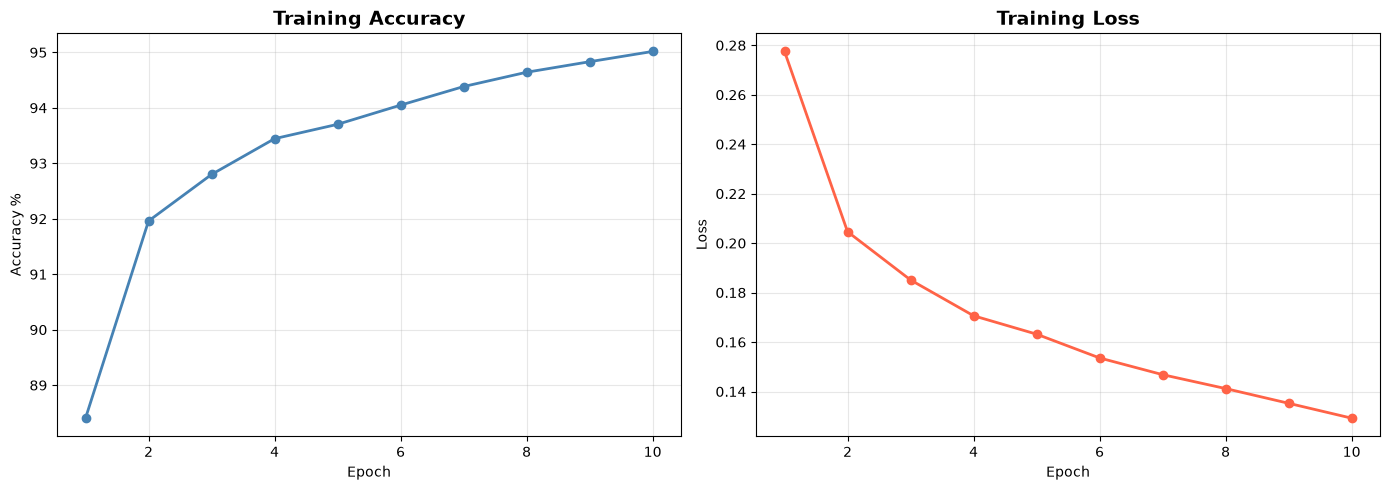

✅ Saved to outputs/training_history.png


In [5]:
# Cell 5 - Plot training results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(range(1, EPOCHS+1), train_accuracies, 
             marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Training Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy %')
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(range(1, EPOCHS+1), train_losses, 
             marker='o', linewidth=2, color='tomato')
axes[1].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/training_history.png', dpi=150)
plt.show()
print("✅ Saved to outputs/training_history.png")

In [6]:
# Cell 6 - Save the model
import torch
import os

os.makedirs('../models', exist_ok=True)
torch.save(model.state_dict(), '../models/cifake_cnn.pth')
print("✅ Model saved to models/cifake_cnn.pth")

✅ Model saved to models/cifake_cnn.pth


In [7]:
# Cell 7 - Test accuracy
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        outputs = model(images)
        predicted = (outputs >= 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total * 100
print(f"✅ Test Accuracy: {test_accuracy:.2f}%")

✅ Test Accuracy: 93.45%


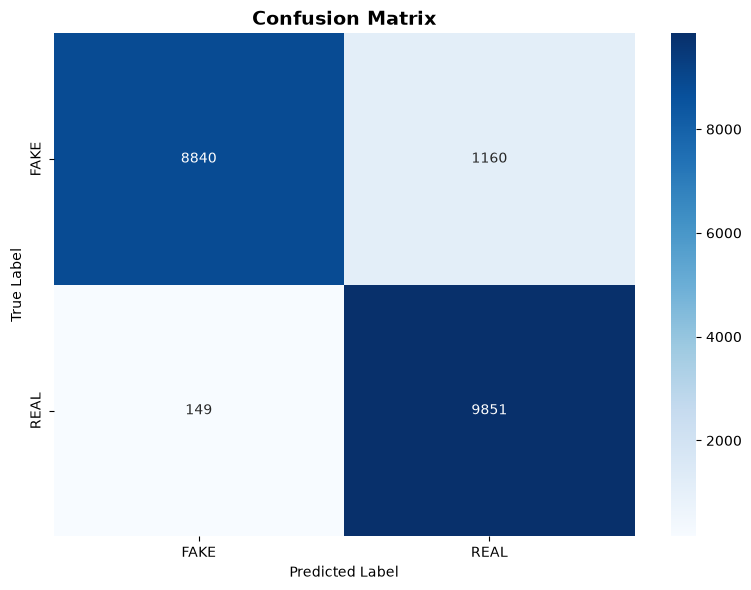


Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.88      0.93     10000
        REAL       0.89      0.99      0.94     10000

    accuracy                           0.93     20000
   macro avg       0.94      0.93      0.93     20000
weighted avg       0.94      0.93      0.93     20000



In [8]:
# Cell 8 - Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predicted = (outputs >= 0.5).float().cpu().numpy()
        all_preds.extend(predicted)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE', 'REAL'],
            yticklabels=['FAKE', 'REAL'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150)
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, 
                            target_names=['FAKE', 'REAL']))